In [27]:
import os

BASE_DIR = "/content/drive/MyDrive/age_gender"

folders = [
    BASE_DIR,
    f"{BASE_DIR}/raw",
    f"{BASE_DIR}/preprocessed",
    f"{BASE_DIR}/labels",
    f"{BASE_DIR}/splits",
    f"{BASE_DIR}/models",
    f"{BASE_DIR}/logs"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

folders

['/content/drive/MyDrive/age_gender',
 '/content/drive/MyDrive/age_gender/raw',
 '/content/drive/MyDrive/age_gender/preprocessed',
 '/content/drive/MyDrive/age_gender/labels',
 '/content/drive/MyDrive/age_gender/splits',
 '/content/drive/MyDrive/age_gender/models',
 '/content/drive/MyDrive/age_gender/logs']

In [28]:
!cp -r /content/part3/* /content/drive/MyDrive/age_gender/raw/

In [5]:
import cv2
import numpy as np
from mtcnn import MTCNN
from tqdm import tqdm
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

In [29]:
RAW = "/content/drive/MyDrive/age_gender/raw"
PREP = "/content/drive/MyDrive/age_gender/preprocessed"

os.makedirs(PREP, exist_ok=True)

detector = MTCNN()

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (128, 128))
    return face

for age_group in os.listdir(RAW):
    src_folder = os.path.join(RAW, age_group)
    if not os.path.isdir(src_folder):
        continue

    dst_folder = os.path.join(PREP, age_group)
    os.makedirs(dst_folder, exist_ok=True)

    for fn in tqdm(os.listdir(src_folder), desc=f"Processing {age_group}"):
        img_path = os.path.join(src_folder, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        det = detector.detect_faces(img)
        if not det:
            continue

        det = sorted(det, key=lambda d: d['box'][2] * d['box'][3], reverse=True)
        face = preprocess_face(img, det[0]['box'])
        if face is None:
            continue

        out_name = os.path.splitext(fn)[0] + ".jpg"
        cv2.imwrite(os.path.join(dst_folder, out_name), face)

print("✔ Preprocessing completed and ALL saved to Drive")

Processing 36+: 100%|██████████| 1660/1660 [09:50<00:00,  2.81it/s]

✔ Preprocessing completed and ALL saved to Drive


In [30]:
import re
import pandas as pd

def extract_gender(fn):
    fn_l = fn.lower()

    m = re.search(r"_(0|1)_", fn_l)
    if m:
        return "male" if m.group(1) == "0" else "female"

    if fn_l.endswith("b.jpg") or "_b" in fn_l:
        return "male"
    if fn_l.endswith("g.jpg") or "_g" in fn_l:
        return "female"

    return None

rows = []

for age_group in os.listdir(PREP):
    folder = os.path.join(PREP, age_group)
    if not os.path.isdir(folder):
        continue

    for fn in os.listdir(folder):
        if not fn.endswith(".jpg"):
            continue

        gender = extract_gender(fn)
        if gender is None:
            continue

        rows.append([f"{age_group}/{fn}", age_group, gender])

df = pd.DataFrame(rows, columns=["filepath", "age_group", "gender"])
df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv", index=False)

df.head(), df["age_group"].value_counts()


(                                     filepath age_group  gender
 0   1-12/9_1_2_20161219204347420.jpg.chip.jpg      1-12  female
 1   1-12/1_1_3_20161219230734016.jpg.chip.jpg      1-12  female
 2            1-12/8_1_0_20170117154607954.jpg      1-12  female
 3  1-12/10_0_1_20170110223848885.jpg.chip.jpg      1-12    male
 4   1-12/3_0_3_20161219225157056.jpg.chip.jpg      1-12    male,
 age_group
 1-12     2048
 36+      1480
 20-35    1459
 13-19     905
 Name: count, dtype: int64)

In [31]:
PREP = "/content/drive/MyDrive/age_gender/preprocessed"
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv")

df_clean = df[df["filepath"].apply(lambda x: os.path.exists(os.path.join(PREP, x)))]

df_clean.to_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv", index=False)

print("Before:", len(df))
print("After cleaning:", len(df_clean))

Before: 5892
After cleaning: 5892


In [32]:
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv")

target = df["age_group"].value_counts().max()

balanced = []
for ag, sub in df.groupby("age_group"):
    balanced.append(sub.sample(target, replace=True, random_state=42))

balanced_df = pd.concat(balanced).sample(frac=1).reset_index(drop=True)
balanced_df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv", index=False)

balanced_df["age_group"].value_counts()

,count
age_group,
1-12,2048
20-35,2048
13-19,2048
36+,2048


In [33]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df, test_size=0.20, stratify=balanced_df["age_group"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["age_group"], random_state=42
)

train_df.to_csv("/content/drive/MyDrive/age_gender/splits/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/age_gender/splits/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/age_gender/splits/test.csv", index=False)

In [12]:
train_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/age_gender/splits/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/age_gender/splits/test.csv")

In [13]:
age_map = {"1-12":0, "13-19":1, "20-35":2, "36+":3}
gender_map = {"male":0, "female":1}

for df_ in [train_df, val_df, test_df]:
    df_["age_id"] = df_["age_group"].map(age_map)
    df_["gender_id"] = df_["gender"].map(gender_map)

In [19]:
def load_image(filepath, gender, age):
    img = tf.io.read_file("/content/drive/MyDrive/age_gender/preprocessed/" + filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (128, 128)) / 255.0
    return img, {"gender_output":tf.cast(gender, tf.float32),
                 "age_output": tf.one_hot(age, 4)
}

In [23]:
base_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
])

In [24]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch = tf.shape(x)[0]
    idx = tf.random.shuffle(tf.range(batch))

    mixed_x = lam * x + (1 - lam) * tf.gather(x, idx)

    mixed_y = {
        "gender_output": lam * y["gender_output"] + (1 - lam) * tf.gather(y["gender_output"], idx),
        "age_output": y["age_output"]
    }
    return mixed_x, mixed_y

In [25]:
def make_ds(df, mix=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"], df["gender_id"], df["age_id"])
    ).map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(lambda x,y: (base_aug(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(32)
    if mix:
        ds = ds.map(lambda x,y: mixup(x,y), num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, mix=True)
val_ds   = make_ds(val_df, mix=False)
test_ds  = make_ds(test_df, mix=False)

In [26]:
class DropBlock2D(layers.Layer):
    def __init__(self, drop_prob=0.1, block_size=5):
        super().__init__()
        self.drop_prob = drop_prob
        self.block_size = block_size

    def call(self, x, training=False):
        if not training:
            return x
        gamma = self.drop_prob / (self.block_size**2)
        mask = tf.cast(tf.random.uniform(tf.shape(x)[:3]) < gamma, x.dtype)
        mask = tf.expand_dims(mask, -1)
        mask = tf.nn.max_pool(mask, ksize=self.block_size, strides=1, padding="SAME")
        return x * (1 - mask)

In [27]:
def res_block(x, filters):
    s = x
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, s])
    x = layers.ReLU()(x)
    x = DropBlock2D(0.1)(x)
    return x

In [28]:
def build_model():
    inp = layers.Input((128,128,3))

    x = layers.Conv2D(32, 7, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = res_block(x, 32)
    x = res_block(x, 32)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = res_block(x, 64)
    x = res_block(x, 64)

    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = res_block(x, 128)
    x = res_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    gender = layers.Dense(2, activation="softmax", name="gender_output")(x)
    age = layers.Dense(4, activation="softmax", name="age_output")(x)

    return models.Model(inp, [gender, age])

In [34]:
steps = len(train_df) // 32

lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=steps * 35
)

optimizer = tf.keras.optimizers.Adam(lr)

losses = {
    "gender_output": tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    "age_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
}

In [35]:
model = build_model()

model.compile(
    optimizer=optimizer,
    loss=losses,
    metrics={
        "gender_output": "accuracy",
        "age_output": "accuracy"
    }
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/age_gender/models/best_model.h5",
    monitor="val_age_output_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[checkpoint_cb]
)

Epoch 1/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - age_output_accuracy: 0.4208 - age_output_loss: 1.2714 - gender_output_accuracy: 0.3482 - gender_output_loss: 0.6731 - loss: 1.9444

205/205 ━━━━━━━━━━━━━━━━━━━━ 607s 3s/step - age_output_accuracy: 0.4211 - age_output_loss: 1.2708 - gender_output_accuracy: 0.3483 - gender_output_loss: 0.6730 - loss: 1.9438 - val_age_output_accuracy: 0.4725 - val_age_output_loss: 1.1432 - val_gender_output_accuracy: 0.5287 - val_gender_output_loss: 0.6863 - val_loss: 1.8249
Epoch 2/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - age_output_accuracy: 0.6026 - age_output_loss: 0.9934 - gender_output_accuracy: 0.3782 - gender_output_loss: 0.6262 - loss: 1.6196

205/205 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - age_output_accuracy: 0.6026 - age_output_loss: 0.9933 - gender_output_accuracy: 0.3781 - gender_output_loss: 0.6262 - loss: 1.6195 - val_age_output_accuracy: 0.5507 - val_age_output_loss: 1.2651 - val_gender_output_accuracy: 0.7326 - val_gender_output_loss: 0.5925 - val_loss: 1.8560
Epoch 3/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - age_output_accuracy: 0.6576 - age_output_loss: 0.9309 - gender_output_accuracy: 0.3622 - gender_output_loss: 0.6129 - loss: 1.5437

205/205 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - age_output_accuracy: 0.6577 - age_output_loss: 0.9308 - gender_output_accuracy: 0.3622 - gender_output_loss: 0.6128 - loss: 1.5436 - val_age_output_accuracy: 0.6984 - val_age_output_loss: 0.8905 - val_gender_output_accuracy: 0.7094 - val_gender_output_loss: 0.5780 - val_loss: 1.4712
Epoch 4/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - age_output_accuracy: 0.6887 - age_output_loss: 0.8927 - gender_output_accuracy: 0.3869 - gender_output_loss: 0.5997 - loss: 1.4924 - val_age_output_accuracy: 0.6288 - val_age_output_loss: 0.9757 - val_gender_output_accuracy: 0.7558 - val_gender_output_loss: 0.5305 - val_loss: 1.5057
Epoch 5/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - age_output_accuracy: 0.7139 - age_output_loss: 0.8595 - gender_output_accuracy: 0.4079 - gender_output_loss: 0.5892 - loss: 1.4487 - val_age_output_accuracy: 0.4029 - val_age_output_loss: 1.5089 - val_gender_output_accuracy: 0.7436 - val_gender_output_loss: 0.5376 - val_loss: 2

205/205 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - age_output_accuracy: 0.7181 - age_output_loss: 0.8481 - gender_output_accuracy: 0.3961 - gender_output_loss: 0.5776 - loss: 1.4258 - val_age_output_accuracy: 0.7167 - val_age_output_loss: 0.8282 - val_gender_output_accuracy: 0.6984 - val_gender_output_loss: 0.6029 - val_loss: 1.4319
Epoch 7/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - age_output_accuracy: 0.7336 - age_output_loss: 0.8309 - gender_output_accuracy: 0.4000 - gender_output_loss: 0.5735 - loss: 1.4044 - val_age_output_accuracy: 0.6667 - val_age_output_loss: 0.9167 - val_gender_output_accuracy: 0.6935 - val_gender_output_loss: 0.5989 - val_loss: 1.5146
Epoch 8/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - age_output_accuracy: 0.7321 - age_output_loss: 0.8271 - gender_output_accuracy: 0.4153 - gender_output_loss: 0.5682 - loss: 1.3953

...

205/205 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - age_output_accuracy: 0.8128 - age_output_loss: 0.6927 - gender_output_accuracy: 0.4244 - gender_output_loss: 0.5248 - loss: 1.2175 - val_age_output_accuracy: 0.8376 - val_age_output_loss: 0.6715 - val_gender_output_accuracy: 0.8278 - val_gender_output_loss: 0.4475 - val_loss: 1.1177
Epoch 22/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - age_output_accuracy: 0.8238 - age_output_loss: 0.6873 - gender_output_accuracy: 0.4409 - gender_output_loss: 0.5164 - loss: 1.2037 - val_age_output_accuracy: 0.8364 - val_age_output_loss: 0.6804 - val_gender_output_accuracy: 0.8144 - val_gender_output_loss: 0.4529 - val_loss: 1.1325
Epoch 23/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - age_output_accuracy: 0.8151 - age_output_loss: 0.6973 - gender_output_accuracy: 0.4388 - gender_output_loss: 0.5163 - loss: 1.2136 - val_age_output_accuracy: 0.8242 - val_age_output_loss: 0.6890 - val_gender_output_accuracy: 0.8339 - val_gender_output_loss: 0.4303 - val_loss:

205/205 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - age_output_accuracy: 0.8315 - age_output_loss: 0.6763 - gender_output_accuracy: 0.4487 - gender_output_loss: 0.5089 - loss: 1.1851 - val_age_output_accuracy: 0.8462 - val_age_output_loss: 0.6517 - val_gender_output_accuracy: 0.8486 - val_gender_output_loss: 0.4178 - val_loss: 1.0683
Epoch 25/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - age_output_accuracy: 0.8263 - age_output_loss: 0.6721 - gender_output_accuracy: 0.4427 - gender_output_loss: 0.5090 - loss: 1.1811 - val_age_output_accuracy: 0.8132 - val_age_output_loss: 0.6792 - val_gender_output_accuracy: 0.8596 - val_gender_output_loss: 0.4030 - val_loss: 1.0834
Epoch 26/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - age_output_accuracy: 0.8367 - age_output_loss: 0.6652 - gender_output_accuracy: 0.4506 - gender_output_loss: 0.5058 - loss: 1.1709 - val_age_output_accuracy: 0.8413 - val_age_output_loss: 0.6471 - val_gender_output_accuracy: 0.8535 - val_gender_output_loss: 0.4013 - val_loss:

205/205 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - age_output_accuracy: 0.8350 - age_output_loss: 0.6595 - gender_output_accuracy: 0.4459 - gender_output_loss: 0.5092 - loss: 1.1687 - val_age_output_accuracy: 0.8523 - val_age_output_loss: 0.6318 - val_gender_output_accuracy: 0.8486 - val_gender_output_loss: 0.4062 - val_loss: 1.0404
Epoch 28/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - age_output_accuracy: 0.8395 - age_output_loss: 0.6504 - gender_output_accuracy: 0.4407 - gender_output_loss: 0.5042 - loss: 1.1546 - val_age_output_accuracy: 0.8523 - val_age_output_loss: 0.6369 - val_gender_output_accuracy: 0.8584 - val_gender_output_loss: 0.4095 - val_loss: 1.0471
Epoch 29/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - age_output_accuracy: 0.8388 - age_output_loss: 0.6534 - gender_output_accuracy: 0.4218 - gender_output_loss: 0.5135 - loss: 1.1669 - val_age_output_accuracy: 0.8510 - val_age_output_loss: 0.6165 - val_gender_output_accuracy: 0.8608 - val_gender_output_loss: 0.3931 - val_loss:

205/205 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - age_output_accuracy: 0.8368 - age_output_loss: 0.6560 - gender_output_accuracy: 0.4595 - gender_output_loss: 0.4959 - loss: 1.1519 - val_age_output_accuracy: 0.8596 - val_age_output_loss: 0.6180 - val_gender_output_accuracy: 0.8669 - val_gender_output_loss: 0.3919 - val_loss: 1.0114
Epoch 31/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - age_output_accuracy: 0.8481 - age_output_loss: 0.6396 - gender_output_accuracy: 0.4465 - gender_output_loss: 0.4984 - loss: 1.1380 - val_age_output_accuracy: 0.8559 - val_age_output_loss: 0.6159 - val_gender_output_accuracy: 0.8645 - val_gender_output_loss: 0.3912 - val_loss: 1.0081
Epoch 32/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - age_output_accuracy: 0.8434 - age_output_loss: 0.6459 - gender_output_accuracy: 0.4523 - gender_output_loss: 0.4970 - loss: 1.1429

205/205 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - age_output_accuracy: 0.8434 - age_output_loss: 0.6459 - gender_output_accuracy: 0.4523 - gender_output_loss: 0.4970 - loss: 1.1428 - val_age_output_accuracy: 0.8718 - val_age_output_loss: 0.6131 - val_gender_output_accuracy: 0.8535 - val_gender_output_loss: 0.3914 - val_loss: 1.0063
Epoch 33/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - age_output_accuracy: 0.8494 - age_output_loss: 0.6421 - gender_output_accuracy: 0.4546 - gender_output_loss: 0.4992 - loss: 1.1412 - val_age_output_accuracy: 0.8632 - val_age_output_loss: 0.6226 - val_gender_output_accuracy: 0.8620 - val_gender_output_loss: 0.3891 - val_loss: 1.0131
Epoch 34/35
205/205 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - age_output_accuracy: 0.8486 - age_output_loss: 0.6452 - gender_output_accuracy: 0.4393 - gender_output_loss: 0.5046 - loss: 1.1498 - val_age_output_accuracy: 0.8608 - val_age_output_loss: 0.6161 - val_gender_output_accuracy: 0.8706 - val_gender_output_loss: 0.3890 - val_loss:

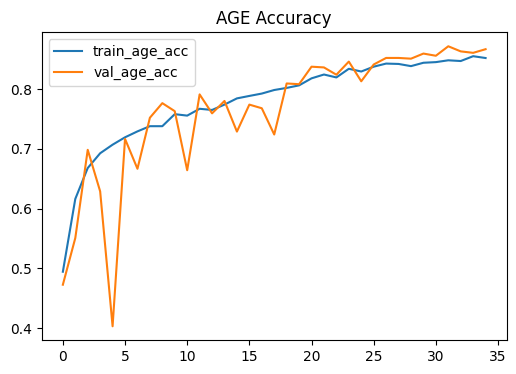

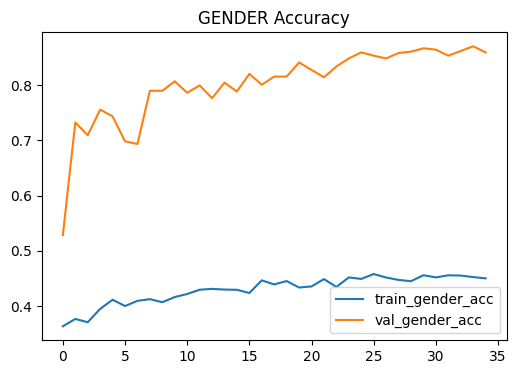

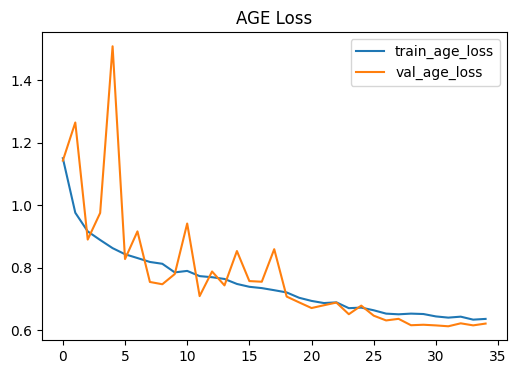

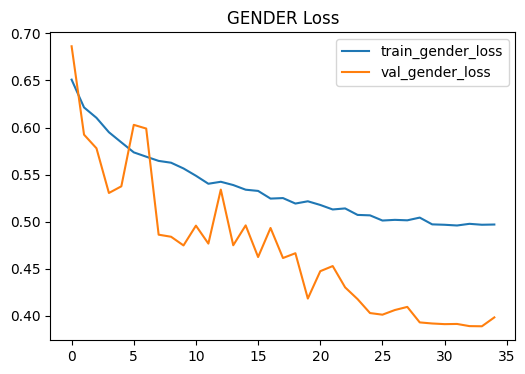

In [36]:
import matplotlib.pyplot as plt

# --- AGE ACCURACY ---
plt.figure(figsize=(6,4))
plt.plot(history.history['age_output_accuracy'], label='train_age_acc')
plt.plot(history.history['val_age_output_accuracy'], label='val_age_acc')
plt.title("AGE Accuracy")
plt.legend()
plt.show()

# --- GENDER ACCURACY ---
plt.figure(figsize=(6,4))
plt.plot(history.history['gender_output_accuracy'], label='train_gender_acc')
plt.plot(history.history['val_gender_output_accuracy'], label='val_gender_acc')
plt.title("GENDER Accuracy")
plt.legend()
plt.show()

# --- AGE LOSS ---
plt.figure(figsize=(6,4))
plt.plot(history.history['age_output_loss'], label='train_age_loss')
plt.plot(history.history['val_age_output_loss'], label='val_age_loss')
plt.title("AGE Loss")
plt.legend()
plt.show()

# --- GENDER LOSS ---
plt.figure(figsize=(6,4))
plt.plot(history.history['gender_output_loss'], label='train_gender_loss')
plt.plot(history.history['val_gender_output_loss'], label='val_gender_loss')
plt.title("GENDER Loss")
plt.legend()
plt.show()


In [37]:
train_age = history.history['age_output_accuracy'][-1]
val_age   = history.history['val_age_output_accuracy'][-1]

train_gender = history.history['gender_output_accuracy'][-1]
val_gender   = history.history['val_gender_output_accuracy'][-1]

print("Age train/val:", train_age, val_age)
print("Gender train/val:", train_gender, val_gender)

Age train/val: 0.852128803730011 0.8669108748435974
Gender train/val: 0.4501754939556122 0.8595848679542542


In [38]:
test_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/test.csv")

test_df["age_id"] = test_df["age_group"].map(age_map)
test_df["gender_id"] = test_df["gender"].map(gender_map)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"], test_df["gender_id"], test_df["age_id"])
).map(load_image).batch(32)

test_metrics = model.evaluate(test_ds)
test_metrics


26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - age_output_accuracy: 0.8658 - age_output_loss: 0.5818 - gender_output_accuracy: 0.8694 - gender_output_loss: 0.3890 - loss: 0.9708


[0.9586052894592285,
 0.37647345662117004,
 0.5827770829200745,
 0.8756097555160522,
 0.8804877996444702]

In [2]:
RAW_13 = "/content/drive/MyDrive/age_gender/raw/13-19"
PREP_13 = "/content/drive/MyDrive/age_gender/preprocessed/13-19"

In [3]:
!pip install lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00


In [4]:
#!pip uninstall -y mtcnn
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 14.7 MB/s eta 0:00:00


In [6]:
from mtcnn import MTCNN
import cv2, os
from tqdm import tqdm

detector = MTCNN()

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (128, 128))
    return face

for fn in tqdm(os.listdir(RAW_13)):
    src = os.path.join(RAW_13, fn)
    out_name = os.path.splitext(fn)[0] + ".jpg"
    dst = os.path.join(PREP_13, out_name)

    # Skip already processed images
    if os.path.exists(dst):
        continue

    img = cv2.imread(src)
    if img is None:
        continue

    det = detector.detect_faces(img)
    if not det:
        continue

    det = sorted(det, key=lambda d: d['box'][2] * d['box'][3], reverse=True)
    face = preprocess_face(img, det[0]['box'])
    if face is not None:
        cv2.imwrite(dst, face)


100%|██████████| 1014/1014 [01:06<00:00, 15.28it/s]


In [7]:
import os, re, pandas as pd

PREP = "/content/drive/MyDrive/age_gender/preprocessed"
rows = []

def extract_gender(fn):
    fn_low = fn.lower()

    m = re.search(r"_(0|1)_", fn_low)
    if m:
        return "male" if m.group(1) == "0" else "female"

    if "_b" in fn_low:
        return "male"
    if "_g" in fn_low:
        return "female"

    return None

for age_group in os.listdir(PREP):
    folder = os.path.join(PREP, age_group)
    if not os.path.isdir(folder):
        continue

    for fn in os.listdir(folder):
        if fn.endswith(".jpg"):
            gender = extract_gender(fn)
            if gender:
                rows.append([f"{age_group}/{fn}", age_group, gender])

df = pd.DataFrame(rows, columns=["filepath", "age_group", "gender"])
df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv", index=False)

In [8]:
PREP = "/content/drive/MyDrive/age_gender/preprocessed"

df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_raw.csv")
df_clean = df[df["filepath"].apply(lambda x: os.path.exists(os.path.join(PREP, x)))]

df_clean.to_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv", index=False)

print("Before:", len(df))
print("After:", len(df_clean))

Before: 5932
After: 5932


In [18]:
df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_clean.csv")

max_count = df["age_group"].value_counts().max()

balanced = []
for ag, sub in df.groupby("age_group"):
    balanced.append(sub.sample(max_count, replace=True, random_state=42))

balanced_df = pd.concat(balanced).sample(frac=1).reset_index(drop=True)
balanced_df.to_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv", index=False)

balanced_df["age_group"].value_counts()

NameError: name 'pd' is not defined

In [10]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/age_gender/labels/labels_balanced.csv")

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["age_group"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["age_group"], random_state=42
)

train_df.to_csv("/content/drive/MyDrive/age_gender/splits/train.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/age_gender/splits/val.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/age_gender/splits/test.csv", index=False)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers

class DropBlock2D(layers.Layer):
    def __init__(self, drop_prob=0.1, block_size=5, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob
        self.block_size = block_size

    def call(self, x, training=False):
        if not training:
            return x
        gamma = self.drop_prob / (self.block_size ** 2)
        mask = tf.cast(tf.random.uniform(tf.shape(x)[:3]) < gamma, x.dtype)
        mask = tf.expand_dims(mask, -1)
        mask = tf.nn.max_pool(mask, ksize=self.block_size, strides=1, padding="SAME")
        return x * (1 - mask)

In [4]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/best_model.h5",
    custom_objects={'DropBlock2D': DropBlock2D},
    compile=False
)

In [6]:
model.save("/content/drive/MyDrive/age_gender/models/model_v1.keras", save_format="keras_v3")

# **FEW SHOT LEARNING ON OCCLUSION**

In [6]:
RAW = "/content/drive/MyDrive/age_gender/occlusion_finetune"
PREP = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed"

os.makedirs(PREP, exist_ok=True)

detector = MTCNN()

def preprocess_face(img, box, pad_ratio=0.25):
    x, y, w, h = box
    H, W = img.shape[:2]

    pad_w = int(w * pad_ratio)
    pad_h = int(h * pad_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]
    if face.size == 0:
        return None

    face = cv2.resize(face, (128, 128))
    return face

for age_group in os.listdir(RAW):
    src_folder = os.path.join(RAW, age_group)
    if not os.path.isdir(src_folder):
        continue

    dst_folder = os.path.join(PREP, age_group)
    os.makedirs(dst_folder, exist_ok=True)

    for fn in tqdm(os.listdir(src_folder), desc=f"Processing {age_group}"):
        img_path = os.path.join(src_folder, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        det = detector.detect_faces(img)
        if not det:
            continue

        det = sorted(det, key=lambda d: d['box'][2] * d['box'][3], reverse=True)
        face = preprocess_face(img, det[0]['box'])
        if face is None:
            continue

        out_name = os.path.splitext(fn)[0] + ".jpg"
        cv2.imwrite(os.path.join(dst_folder, out_name), face)

print("✔ Preprocessing completed and ALL saved to Drive")

Processing 36+: 100%|██████████| 18/18 [00:29<00:00,  1.64s/it]

✔ Preprocessing completed and ALL saved to Drive


In [16]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v1.keras",
    custom_objects={"DropBlock2D": DropBlock2D},
    compile=False
)

print("Loaded model_v1")

Loaded model_v1


In [5]:
# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze last 8–10 layers (recommended)
for layer in model.layers[-10:]:
    layer.trainable = True

print("Trainable layers:")
for l in model.layers[-15:]:
    print(l.name, l.trainable)

Trainable layers:
re_lu_49 False
drop_block2d_4 False
conv2d_58 False
batch_normalization_50 False
re_lu_50 False
conv2d_59 True
batch_normalization_51 True
add_23 True
re_lu_51 True
drop_block2d_5 True
global_average_pooling2d_3 True
dense_3 True
dropout_3 True
gender_output True
age_output True


In [6]:
import os
import tensorflow as tf

IMG_SIZE = 128
BATCH = 8

# ---------------------------------------------------------
# 1. Build file list
# ---------------------------------------------------------
base = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed"

fewshot_paths = []

for grp in ["1-12", "13-19", "20-35", "36+"]:
    folder = f"{base}/{grp}"
    if not os.path.exists(folder):
        print("❌ Missing folder:", folder)
        continue

    for f in os.listdir(folder):
        if f.lower().endswith(".jpg"):
            fewshot_paths.append(os.path.join(folder, f))

print("Few-shot samples:", len(fewshot_paths))


# ---------------------------------------------------------
# 2. Label extraction function (Python side)
# ---------------------------------------------------------
def load_and_label(path):
    path = path.numpy().decode()

    # --- Load & preprocess image ---
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # --- Extract age group from folder ---
    age_group = path.split("/")[-2]
    age_map = {"1-12": 0, "13-19": 1, "20-35": 2, "36+": 3}
    age_label = age_map[age_group]

    # --- Extract gender from filename ---
    fname = path.split("/")[-1].lower()

    fname = path.split("/")[-1].lower()

    # Allow _b, _b_, b_, _g, g_, etc.
    if "_b" in fname or "b_" in fname:
        gender_label = 0    # male
    elif "_g" in fname or "g_" in fname:
        gender_label = 1    # female
    else:
        raise ValueError(f"❌ Could not detect gender from filename: {fname}")

    return img, gender_label, age_label


# ---------------------------------------------------------
# 3. Parse record (TensorFlow side)
# ---------------------------------------------------------
def parse_record(path):
    img, gender, age = tf.py_function(
        load_and_label,
        [path],
        [tf.float32, tf.int32, tf.int32]
    )

    # 🔥 VERY IMPORTANT: set shapes manually
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    gender.set_shape([])
    age.set_shape([])

    return img, gender, age


# ---------------------------------------------------------
# 4. Build raw dataset
# ---------------------------------------------------------
fewshot_ds = tf.data.Dataset.from_tensor_slices(fewshot_paths)
fewshot_ds = fewshot_ds.shuffle(len(fewshot_paths))
fewshot_ds = fewshot_ds.map(parse_record, num_parallel_calls=tf.data.AUTOTUNE)


# ---------------------------------------------------------
# 5. Convert to model format (dual output)
# ---------------------------------------------------------
def format_labels(img, gender, age):
    return img, {
        "gender_output": gender,
        "age_output": age
    }

fewshot_ds = fewshot_ds.map(format_labels)
fewshot_ds = fewshot_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("✔ Few-shot dataset ready!")

Few-shot samples: 110
✔ Few-shot dataset ready!


In [7]:
for batch in fewshot_ds.take(1):
    print("image batch:", batch[0].shape)
    print("gender batch:", batch[1]["gender_output"].shape)
    print("age batch:", batch[1]["age_output"].shape)

image batch: (8, 128, 128, 3)
gender batch: (8,)
age batch: (8,)


In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        "age_output": tf.keras.losses.SparseCategoricalCrossentropy(),
        "gender_output": tf.keras.losses.BinaryCrossentropy()
    },
    metrics={
        "age_output": "accuracy",
        "gender_output": "accuracy"
    }
)

In [9]:
history = model.fit(
    fewshot_ds,
    epochs=5
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 741ms/step - age_output_accuracy: 0.5091 - age_output_loss: 1.2943 - gender_output_accuracy: 0.7463 - gender_output_loss: 0.5577 - loss: 1.8533
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - age_output_accuracy: 0.4790 - age_output_loss: 1.3887 - gender_output_accuracy: 0.8188 - gender_output_loss: 0.4518 - loss: 1.8405
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - age_output_accuracy: 0.4131 - age_output_loss: 1.4206 - gender_output_accuracy: 0.7816 - gender_output_loss: 0.4786 - loss: 1.9002
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - age_output_accuracy: 0.4531 - age_output_loss: 1.3443 - gender_output_accuracy: 0.7364 - gender_output_loss: 0.4969 - loss: 1.8416
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - age_output_accuracy: 0.4997 - age_output_loss: 1.2696 - gender_output_accuracy: 0.8839 - gender_output_loss: 0.4200 - loss: 1.6897


In [10]:
model.save("/content/drive/MyDrive/age_gender/models/model_v2_fewshot.keras")

print("Few-shot finetuned model saved!")

Few-shot finetuned model saved!


# **EVALUATION BEFORE VS AFTER FINE TUNING**

In [1]:
PREP_PATH = "/content/drive/MyDrive/age_gender/preprocessed"

In [2]:
import os
import tensorflow as tf
import pandas as pd
import numpy as np

# Load val csv
val_df = pd.read_csv("/content/drive/MyDrive/age_gender/splits/val.csv")

# Build correct full paths
val_df["full_path"] = val_df["filepath"].apply(
    lambda x: os.path.join(PREP_PATH, x)
)

print(val_df["full_path"].head())


0    /content/drive/MyDrive/age_gender/preprocessed...
1    /content/drive/MyDrive/age_gender/preprocessed...
2    /content/drive/MyDrive/age_gender/preprocessed...
3    /content/drive/MyDrive/age_gender/preprocessed...
4    /content/drive/MyDrive/age_gender/preprocessed...
Name: full_path, dtype: object


In [3]:
age_map = {"1-12":0, "13-19":1, "20-35":2, "36+":3}
gender_map = {"male":0, "female":1}

val_df["age_label"] = val_df["age_group"].map(age_map)
val_df["gender_label"] = val_df["gender"].map(gender_map)

In [4]:
IMG_SIZE = 128

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0


In [5]:
val_imgs = tf.data.Dataset.from_tensor_slices(val_df["full_path"])
val_imgs = val_imgs.map(load_image).batch(32)

y_true_age = val_df["age_label"].values
y_true_gender = val_df["gender_label"].values

In [8]:
base_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v1.keras",
    custom_objects={"DropBlock2D": DropBlock2D}
)

ft_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v2_fewshot.keras",
    custom_objects={"DropBlock2D": DropBlock2D}
)

print("Loaded both models successfully!")

Loaded both models successfully!


In [9]:
pred_v1 = base_model.predict(val_imgs)
pred_v2 = ft_model.predict(val_imgs)

gender_pred_v1 = np.argmax(pred_v1[0], axis=1)
gender_pred_v2 = np.argmax(pred_v2[0], axis=1)

age_pred_v1 = np.argmax(pred_v1[1], axis=1)
age_pred_v2 = np.argmax(pred_v2[1], axis=1)

# Accuracy
acc_v1_gender = np.mean(gender_pred_v1 == y_true_gender)
acc_v1_age    = np.mean(age_pred_v1 == y_true_age)

acc_v2_gender = np.mean(gender_pred_v2 == y_true_gender)
acc_v2_age    = np.mean(age_pred_v2 == y_true_age)

print("V1 Gender Accuracy:", acc_v1_gender)
print("V1 Age Accuracy:", acc_v1_age)

print("V2 Gender Accuracy:", acc_v2_gender)
print("V2 Age Accuracy:", acc_v2_age)

26/26 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step
V1 Gender Accuracy: 0.5628815628815629
V1 Age Accuracy: 0.8717948717948718
V2 Gender Accuracy: 0.5628815628815629
V2 Age Accuracy: 0.8717948717948718


In [12]:
import tensorflow as tf

model_fs = tf.keras.models.load_model(
    "/content/drive/MyDrive/age_gender/models/model_v2_fewshot.keras",
    custom_objects={"DropBlock2D": DropBlock2D},
    compile=False
)

print("Loaded model_v2")

Loaded model_v2


In [14]:
import cv2
import numpy as np

img_path = "/content/drive/MyDrive/age_gender/occlusion_finetune_preprocessed/1-12/10_b (1).jpg"

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to your model input size
img_resized = cv2.resize(img, (128,128))   # ← use your model size

# Normalize (if used in training)
img_norm = img_resized / 255.0

# Expand dims for model input
img_input = np.expand_dims(img_norm, axis=0)


In [19]:
pred_gender, pred_age = model.predict(img_input)

print("age_pred:", pred_age)
print("gender_pred:", pred_gender)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
age_pred: [[0.10258841 0.7834773  0.07529041 0.03864384]]
gender_pred: [[0.31270608]]
